In [1]:
import pandas as pd
import dask.dataframe as dd
from dask.diagnostics import ProgressBar
import auri
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

In [2]:
pd.options.display.float_format = '{:,.0f}'.format

### - 건축물대장 층별개요 2023년12월 기준 파일을 데이터프레임에 저장

In [3]:
ddf = dd.read_parquet("data\건축물대장_층별개요_2023년_12월", calculate_divisions=True)
ddf.columns

Index(['대지_위치', '도로명_대지_위치', '건물_명', '시군구_코드',
       '법정동_코드', '대지_구분_코드', '번', '지', '특수지_명', '블록',
       '로트', '새주소_도로_코드', '새주소_법정동_코드',
       '새주소_지상지하_코드', '새주소_본_번', '새주소_부_번', '동_명',
       '층_구분_코드', '층_구분_코드_명', '층_번호', '층_번호_명', '구조_코드',
       '구조_코드_명', '기타_구조', '주_용도_코드', '주_용도_코드_명',
       '기타_용도', '면적(㎡)', '주_부속_구분_코드', '주_부속_구분_코드_명',
       '면적_제외_여부', '생성_일자'],
      dtype='object')

In [4]:
ddf.dtypes

대지_위치                string
도로명_대지_위치         string
건물_명                  string
시군구_코드              string
법정동_코드              string
대지_구분_코드           string
번                       string
지                       string
특수지_명                string
블록                     string
로트                     string
새주소_도로_코드         string
새주소_법정동_코드       string
새주소_지상지하_코드     string
새주소_본_번              Int64
새주소_부_번              Int64
동_명                    string
층_구분_코드             string
층_구분_코드_명          string
층_번호                   Int64
층_번호_명               string
구조_코드                string
구조_코드_명             string
기타_구조                string
주_용도_코드             string
주_용도_코드_명          string
기타_용도                string
면적(㎡)                float64
주_부속_구분_코드        string
주_부속_구분_코드_명     string
면적_제외_여부           string
생성_일자                string
dtype: object

### - 층별개요 컬럼 중 필요한 것 만 가져와서 데이터를 가볍게 함

In [4]:
ddf = ddf[['층_구분_코드', '층_구분_코드_명', '층_번호', '층_번호_명',
       '구조_코드', '구조_코드_명', '기타_구조', '주_용도_코드', '주_용도_코드_명', '기타_용도', '면적(㎡)',
       '주_부속_구분_코드', '면적_제외_여부', '생성_일자']]

In [5]:
ddf.head()

,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,면적(㎡),주_부속_구분_코드,면적_제외_여부,생성_일자
관리_건축물대장_PK,,,,,,,,,,,,,,
0-2998,20,지상,1,1층,21,철근콘크리트구조,철골조,17100,일반공장,공장,"30,923",0,<NA>,20231020
0-2998,10,지하,1,지1,21,철근콘크리트구조,철근콘크리트조,17100,일반공장,기계실,"1,369",0,<NA>,20231020
11110-1000,10,지하,1,지하층,11,벽돌구조,조적조,02002,연립주택,"보일러실,대피실,지하계단실",162,0,<NA>,20200427
11110-1000,20,지상,1,1층,11,벽돌구조,조적조,02002,연립주택,연립주택,387,0,<NA>,20200427
11110-1000,20,지상,2,2층,11,벽돌구조,조적조,02002,연립주택,연립주택,382,0,<NA>,20200427


### - 층별개요 기초적인 통계를 산출
1. 전국 건축물 층수 합 : 전체 레코드 수(합계, 지상층수 합계, 지하층수 합계) -> 산출방법 : 층_구분_코드 별로 레코드 수의 합계를 구함 -> value_counts() -> 20 : 지상, 10 : 지하, 30 : 옥탑, 21 : 복수층(하층), 22 : 복수층(상층), 40 : 각층(집합건축물 전유부 공용부분)

전국 건축물의 지상 층수의 합계는 18,918,491개 층이며, 지하 층수의 합계는 1,520,078개 층이다. 기타로 옥탑은 417,735개가 있으며, 복수층은 6개, 각층은 216개가 있다. 이를 모두 합한 전체 층의 합계는 20,857,076 층이다.

2. 층별 면적의 최대, 최소, 미기재 등 : 층별 면적이 미기재 된 것은 32,333개 층이다. 단일 층으로 최대 면적은 188,957,549.0의 경기 김포의 한강신도시 롯데캐슬의 지하층 부대시설이나 해당 건축물의 표제부 확인 결과 부용도로 대장을 확인할 수 없고 총괄표제부에 기록된 내용도 일치하는 항목을 찾을 수 없음. 따라서 부용도의 경우 층별개요의 연면적이 오류, 결측 등이 다 수 있는 것으로 추정되어, 층별개요의 주용도 중 단일 층 상위 100개 데이터로 확인하고자 함

3. 건축물의 층 중 주용도 층은 19,125,575 개이며, 부용도 층은 1,722,063 개로 확인되며, 주용도 층 중 면적의 최대값은 5,702,939.0으로 이역시 동의하기 어려운 값으로 일반건축물대장 확인 결과 충남 서천에 위치한 공장으로 지상 3층에 기계실로 확인되며, 연면적이 147,691.26으로 콤마 오기로 1000배의 수치가 반영된 것으로 추정

4. 이에, 층별 면적이 표제부 또는 일반건축물대장의 연면적보다 큰 경우는 오기로 보는 것이 타당하여 레코드를 삭제할 필요가 있음


### - 데이터셋 구축 방안

A. 표제부를 기준으로 층별개요에서 필요한 값을 표제부에 붙여서 계산하는 방법
- 건축물의 용도를 기준으로 한다면 제2롯데월드와 같은 대규모 건축물에서 특정 용도면적이 통합되는 경향이 발생할 수 있다.
- 건축물 연령은 단위면적으로 보는 것이 타당하다.
- 동수와 면적을 동시에 활용하는 것이 중요하다면 이방법으로 하는 것이 좋다.
- 부속용도는 삭제해야한다. 연면적에 이미 해당 면적이 포함된다. 이 경우 입체적이라는 장점이 있다.

B. 층별개요를 기준으로 표제부의 사용승인일을 붙여서 계산하는 방법
- 표제부의 사용승인일이 미기재된 것은 삭제... 연령을 알 수가 없다.
- 용도를 층별로 구분하기 때문에 용도가 중요한 경우 이렇게 해야한다.
- 부속용도는 삭제하는 것이 관리가 용이하다. 다만 이경우 건물을 입체로 본다면 현실과는 다르다.

C. 데이터셋 구축 절차
1. 다운로드(표제부, 층별개요)
2. 표제부 사용승인일 가공(사용승인일 표준화 및 데이터 정제)
3. 표제부 키값 및 사용승인일, 주소, 연면적 데이터셋 생성(데이터컬럼 정리)
4. 층별개요 데이터셋 정리(데이터컬럼 정리)
5. 층별개요 데이터셋에 표제부 데이터셋 결합
6. 연령지수 데이터셋 생성
7. 데이터 2차 정제(부속용도, 사용승인일 미기재 삭제 등)


- 건축물 연령을 보는 이유는? 
1. 지역별 노후건축물 현황 파악과 미래 예측 -> 공공에서 안전관리해야 할 물량 산출(예산, 인력), 건축산업 물량 산출(리모델링, 신축), 탄소배출량 등 기후변화 대응
2. 지역별 용도별 건축물의 연령별 재고 파악 -> 주거용/상업용 등 용도별 건축물 공급시기 결정
3. 지역별 건축물 연령 피라미드를 통한 지역 특성 파악 -> 서울시 vs 함안군 다름, 서울시는 피라미드형, 함안군은 표주박형이라면 서울시는 지속적인 개발, 함안군은 개발이 중단된 것으로 향후 인구감소와 경기불황 예상 -> 유동인구, 정주인구 등등 도시관련 공공데이터 항목과 회귀분석을 통하여 원인분석 및 군집
4. 지역별 개발사업의 지표 -> 쇠퇴지역 파악
5. 건축물 연령지표의 가능성 : 도시의 특성을 공공데이터인 건축물데이터로 진단 및 예측할 수 있다. 별도 조사가 불필요하고 실시간으로 변화되는 것으로 도시의 상태를 실시간으로 진단할 수 있다. 

2. 건축물재고지수의 차별화
- 용도별 각 지자체의 건축물 재고를 입체적으로 본다. 입체적(노후도, 인구대비, 산업구조대비, 경제대비).... 제곱미터 당 매출, 제곱미터 당 인구
- 용도별 건축물의 활용 현황을 파악한다.(빈건축물)
- 건축물재고 중 재난에 취약한 건축물 재고를 파악한다.
- 인구, 산업, 경제, 문화를 고려할 때 용도별 건축물의 적정 재고를 파악한다.(전국비교, )



In [6]:
ddf.층_구분_코드.value_counts().compute()

20    18918491
10     1520078
30      417735
40         216
21           6
22           6
Name: 층_구분_코드, dtype: Int64

In [7]:
len(ddf)

20857076

In [26]:
len(ddf[ddf['면적(㎡)']<=0])

32333

In [31]:
ddf['면적(㎡)'].max().compute()

188957549.0

In [34]:
ddf.주_부속_구분_코드.value_counts().compute()

0    19125575
1     1722063
Name: 주_부속_구분_코드, dtype: Int64

In [40]:
with pd.option_context("display.max_rows", None, "display.max_columns", 100):
   display(ddf[ddf['면적(㎡)'] == 5702939.0].compute())
   ## display(ddf[ddf['면적(㎡)']<=0].compute())
   ## display(ddf[ddf['층_구분_코드'] == '40'].compute())
   ## display(ddf[ddf['주_부속_구분_코드'] == '1'].head())

,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,면적(㎡),주_부속_구분_코드,면적_제외_여부,생성_일자
관리_건축물대장_PK,,,,,,,,,,,,,,
44770-4186,20,지상,3,3층,31,일반철골구조,일반철골구조,17100,일반공장,기계실,5702939.0,0,0,20230613


In [48]:
ddf.loc['44770-4186']['면적(㎡)'].sum().compute()

5833307.119

In [6]:
ddf.columns

Index(['층_구분_코드', '층_구분_코드_명', '층_번호', '층_번호_명', '구조_코드',
       '구조_코드_명', '기타_구조', '주_용도_코드', '주_용도_코드_명',
       '기타_용도', '면적(㎡)', '주_부속_구분_코드', '면적_제외_여부',
       '생성_일자'],
      dtype='object')

표제부파일 불러와서 데이터 프레임에 저장하기

In [7]:
dddf = dd.read_parquet("data\건축물대장_표제부_2023년_12월", calculate_divisions=True)
dddf.columns

Index(['대장_구분_코드', '대장_구분_코드_명', '대장_종류_코드',
       '대장_종류_코드_명', '대지_위치', '도로명_대지_위치', '건물_명',
       '시군구_코드', '법정동_코드', '대지_구분_코드', '번', '지', '특수지_명',
       '블록', '로트', '외필지_수', '새주소_도로_코드', '새주소_법정동_코드',
       '새주소_지상지하_코드', '새주소_본_번', '새주소_부_번', '동_명',
       '주_부속_구분_코드', '주_부속_구분_코드_명', '대지_면적(㎡)',
       '건축_면적(㎡)', '건폐_율(%)', '연면적(㎡)', '용적_률_산정_연면적(㎡)',
       '용적_률(%)', '구조_코드', '구조_코드_명', '기타_구조', '주_용도_코드',
       '주_용도_코드_명', '기타_용도', '지붕_코드', '지붕_코드_명',
       '기타_지붕', '세대_수(세대)', '가구_수(가구)', '높이(m)', '지상_층_수',
       '지하_층_수', '승용_승강기_수', '비상용_승강기_수', '부속_건축물_수',
       '부속_건축물_면적(㎡)', '총_동_연면적(㎡)', '옥내_기계식_대수(대)',
       '옥내_기계식_면적(㎡)', '옥외_기계식_대수(대)', '옥외_기계식_면적(㎡)',
       '옥내_자주식_대수(대)', '옥내_자주식_면적(㎡)', '옥외_자주식_대수(대)',
       '옥외_자주식_면적(㎡)', '허가_일', '착공_일', '사용승인_일',
       '허가번호_년', '허가번호_기관_코드', '허가번호_기관_코드_명',
       '허가번호_구분_코드', '허가번호_구분_코드_명', '호_수(호)',
       '에너지효율_등급', '에너지절감_율', '에너지_EPI점수',
       '친환경_건축물_등급', '친환경_건축물_인증점수', '지능형_건축물_등급',
       '지능형_건

표제부 파일에서 기초통계 생산하기
1. 전체 표제부/일반건축물의 동 수 : 7987943 동
2. 주 건축물, 부속건축물의 동 수 : 주(7339450 동), 부(647856 동)
3. 사용승인일 기재여부 : 유(7322826 동), 무(665117 동)
4. 사용승인일과 연면적이 모두 있는 동 수 : 7295644 동
5. 주 건축물이고 사용승인일, 연면적이 모두 있는 동 수 : 6816837 동

In [10]:
len(dddf)

7987943

In [51]:
dddf.주_부속_구분_코드.value_counts().compute()

0    7339450
1     647856
Name: 주_부속_구분_코드, dtype: Int64

In [52]:
dddf.사용승인_일.isnull().value_counts().compute()

False    7322826
True      665117
Name: 사용승인_일, dtype: int64

In [56]:
len(dddf[(dddf['연면적(㎡)']>0) & (~dddf['사용승인_일'].isnull())])

7295644

In [66]:
len(dddf[(dddf['연면적(㎡)']>0) & (~dddf['사용승인_일'].isnull()) & (dddf['주_부속_구분_코드']=='0')])


6816837

표제부 파일 중 필요한 컬럼만 추출하여 데이터셋에 저장

In [8]:
dddf = dddf[['시군구_코드', '법정동_코드','주_부속_구분_코드', '주_부속_구분_코드_명', '대지_면적(㎡)',
       '건축_면적(㎡)', '건폐_율(%)', '연면적(㎡)', '용적_률_산정_연면적(㎡)', '용적_률(%)', '구조_코드',
       '주_용도_코드', '주_용도_코드_명', '기타_용도', '총_동_연면적(㎡)','허가_일',
       '착공_일', '사용승인_일', '생성_일자']]
dddf.columns

Index(['시군구_코드', '법정동_코드', '주_부속_구분_코드',
       '주_부속_구분_코드_명', '대지_면적(㎡)', '건축_면적(㎡)', '건폐_율(%)',
       '연면적(㎡)', '용적_률_산정_연면적(㎡)', '용적_률(%)', '구조_코드',
       '주_용도_코드', '주_용도_코드_명', '기타_용도', '총_동_연면적(㎡)',
       '허가_일', '착공_일', '사용승인_일', '생성_일자'],
      dtype='object')

연도리스트 생성(1년부터 2023년까지, 2023개)

In [9]:
def generate_continuous_strings(start, end):
    """
    Generate a list of continuous strings from start to end.
    """
    year_list = [str(i).zfill(4) for i in range(start, end + 1)]
    return year_list

# Example usage:
year_list = generate_continuous_strings(1, 2023)
print(year_list)

['0001', '0002', '0003', '0004', '0005', '0006', '0007', '0008', '0009', '0010', '0011', '0012', '0013', '0014', '0015', '0016', '0017', '0018', '0019', '0020', '0021', '0022', '0023', '0024', '0025', '0026', '0027', '0028', '0029', '0030', '0031', '0032', '0033', '0034', '0035', '0036', '0037', '0038', '0039', '0040', '0041', '0042', '0043', '0044', '0045', '0046', '0047', '0048', '0049', '0050', '0051', '0052', '0053', '0054', '0055', '0056', '0057', '0058', '0059', '0060', '0061', '0062', '0063', '0064', '0065', '0066', '0067', '0068', '0069', '0070', '0071', '0072', '0073', '0074', '0075', '0076', '0077', '0078', '0079', '0080', '0081', '0082', '0083', '0084', '0085', '0086', '0087', '0088', '0089', '0090', '0091', '0092', '0093', '0094', '0095', '0096', '0097', '0098', '0099', '0100', '0101', '0102', '0103', '0104', '0105', '0106', '0107', '0108', '0109', '0110', '0111', '0112', '0113', '0114', '0115', '0116', '0117', '0118', '0119', '0120', '0121', '0122', '0123', '0124', '0125',

4자리수이나 연도가 아닐 가능성이 있는 월일형식 날짜 리스트 생성(0101부터 1231까지 366개)

In [10]:
from datetime import datetime, timedelta

def generate_date_strings():
    """
    Generate a list of date strings from January 1st to December 31st.
    """
    date_list = []

    # 시작 날짜 설정
    start_date = datetime(2024, 1, 1)

    # 12월 31일까지 반복
    while start_date.year == 2024:
        # 날짜를 '0101' 형식의 문자열로 변환하여 리스트에 추가
        date_str = start_date.strftime('%m%d')
        date_list.append(date_str)

        # 다음 날짜로 이동
        start_date += timedelta(days=1)

    return date_list

# Example usage:
date_list = generate_date_strings()
print(date_list)

['0101', '0102', '0103', '0104', '0105', '0106', '0107', '0108', '0109', '0110', '0111', '0112', '0113', '0114', '0115', '0116', '0117', '0118', '0119', '0120', '0121', '0122', '0123', '0124', '0125', '0126', '0127', '0128', '0129', '0130', '0131', '0201', '0202', '0203', '0204', '0205', '0206', '0207', '0208', '0209', '0210', '0211', '0212', '0213', '0214', '0215', '0216', '0217', '0218', '0219', '0220', '0221', '0222', '0223', '0224', '0225', '0226', '0227', '0228', '0229', '0301', '0302', '0303', '0304', '0305', '0306', '0307', '0308', '0309', '0310', '0311', '0312', '0313', '0314', '0315', '0316', '0317', '0318', '0319', '0320', '0321', '0322', '0323', '0324', '0325', '0326', '0327', '0328', '0329', '0330', '0331', '0401', '0402', '0403', '0404', '0405', '0406', '0407', '0408', '0409', '0410', '0411', '0412', '0413', '0414', '0415', '0416', '0417', '0418', '0419', '0420', '0421', '0422', '0423', '0424', '0425', '0426', '0427', '0428', '0429', '0430', '0501', '0502', '0503', '0504',

날짜일 가능성 배제를 위하여 연도리스트에서 날짜리스트 중복 삭제(최종 1657개)

In [11]:
def create_new_list(list1, list2):
    """
    Create a new list without duplicate items from both lists.
    """
    # 두 리스트를 합친 후 중복을 제거하여 새로운 리스트 생성
    new_list = [item for item in list1 + list2 if (list1 + list2).count(item) == 1]

    return new_list


# 중복값을 제외하고 새로운 리스트 생성
complete_year_list = create_new_list(year_list, date_list)

# 결과 출력
print("연도 추정 리스트:", complete_year_list)

연도 추정 리스트: ['0001', '0002', '0003', '0004', '0005', '0006', '0007', '0008', '0009', '0010', '0011', '0012', '0013', '0014', '0015', '0016', '0017', '0018', '0019', '0020', '0021', '0022', '0023', '0024', '0025', '0026', '0027', '0028', '0029', '0030', '0031', '0032', '0033', '0034', '0035', '0036', '0037', '0038', '0039', '0040', '0041', '0042', '0043', '0044', '0045', '0046', '0047', '0048', '0049', '0050', '0051', '0052', '0053', '0054', '0055', '0056', '0057', '0058', '0059', '0060', '0061', '0062', '0063', '0064', '0065', '0066', '0067', '0068', '0069', '0070', '0071', '0072', '0073', '0074', '0075', '0076', '0077', '0078', '0079', '0080', '0081', '0082', '0083', '0084', '0085', '0086', '0087', '0088', '0089', '0090', '0091', '0092', '0093', '0094', '0095', '0096', '0097', '0098', '0099', '0100', '0132', '0133', '0134', '0135', '0136', '0137', '0138', '0139', '0140', '0141', '0142', '0143', '0144', '0145', '0146', '0147', '0148', '0149', '0150', '0151', '0152', '0153', '0154', '015

사용승인일에서 4자리 사용승인연도를 추출하여 컬럼을 추가(year)하고, 연도추정리스트와 일치하는 지 여부에 대한 컬럼 추가(T_year)하여 새로운 데이터셋(dddf_new)생성

In [12]:
dddf_new = dddf.copy()

dddf_new['year'] = dddf_new.사용승인_일.str.slice(stop=4)
dddf_new['T_year'] = dddf_new['year'].isin(complete_year_list)
## dddf_new = dddf_new[(ddf_new['연면적(㎡)']>0)&(ddf_new['T_year'])&(ddf_new['주_부속_구분_코드'] == '0')]

# 결과 출력
dddf_new.head()


,시군구_코드,법정동_코드,주_부속_구분_코드,주_부속_구분_코드_명,대지_면적(㎡),건축_면적(㎡),건폐_율(%),연면적(㎡),용적_률_산정_연면적(㎡),용적_률(%),...,주_용도_코드,주_용도_코드_명,기타_용도,총_동_연면적(㎡),허가_일,착공_일,사용승인_일,생성_일자,year,T_year
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,
0-2998,0,25321,0,주건축물,"59,451","31,616",0,"32,985","31,616",0,...,17000,공장,공장,"32,985",19980327,19980414,19980824,20231020,1998,True
11110-1000,11110,18200,0,주건축물,0,0,0,"1,152",0,0,...,02000,공동주택,연립주택,"1,152",<NA>,<NA>,19861024,20200427,1986,True
11110-1000000000000000060121,11110,13500,0,주건축물,352,282,80,"1,470","1,365",388,...,04000,제2종근린생활시설,제2종근린생활시설,"1,470",20201231,20210610,20220817,20221031,2022,True
11110-1000000000000000060147,11110,18400,0,주건축물,590,246,42,848,487,83,...,01000,단독주택,단독주택,848,20200203,20200501,20220817,20220928,2022,True
11110-1000000000000000060936,11110,17500,0,주건축물,109,66,61,419,356,326,...,04000,제2종근린생활시설,제2종근린생활시설(제2종근린생활시설(사무소) 및 다중주택)......,419,20210507,20210818,20220818,20220919,2022,True


표제부의 면적에 대한 3개의 칼럼(대지_면적(㎡), 건축_면적(㎡), 연면적(㎡))과 시군구_코드, 법정동_코드, 가공사용승인일(year) 등의 컬럼을 층별개요 컬럼에 관리_건축물대장_PK를 매개로 연결
['시군구_코드', '법정동_코드', '주_부속_구분_코드', '대지_면적(㎡)',
       '건축_면적(㎡)', '연면적(㎡)', '구조_코드',
       '주_용도_코드', '기타_용도', '총_동_연면적(㎡)', 'year', 'T_year']

In [13]:
dddf_new.columns

Index(['시군구_코드', '법정동_코드', '주_부속_구분_코드',
       '주_부속_구분_코드_명', '대지_면적(㎡)', '건축_면적(㎡)', '건폐_율(%)',
       '연면적(㎡)', '용적_률_산정_연면적(㎡)', '용적_률(%)', '구조_코드',
       '주_용도_코드', '주_용도_코드_명', '기타_용도', '총_동_연면적(㎡)',
       '허가_일', '착공_일', '사용승인_일', '생성_일자', 'year', 'T_year'],
      dtype='object')

표제부의 관리_건축물대장_PK값의 중복여부 확인
중복이 없음을 확인

In [14]:
# 데이터프레임 index의 정렬여부 확인
dddf_new.known_divisions

True

In [15]:
##각 파큇의 인덱스 중복여부 확인
uniqs = ddf.map_partitions(lambda d: d.index.is_unique).compute()
uniqs

0     False
1     False
2     False
3     False
4     False
      ...  
74    False
75    False
76    False
77    False
78    False
Length: 79, dtype: bool

In [90]:
uniqs.value_counts()

False    79
dtype: int64

층별개요에 표제부 조인

In [16]:
joined_ddf = ddf.join(dddf_new[['시군구_코드', '법정동_코드', '주_부속_구분_코드', '대지_면적(㎡)',
       '건축_면적(㎡)', '연면적(㎡)', '구조_코드',
       '주_용도_코드', '기타_용도', '총_동_연면적(㎡)', 'year', 'T_year']], rsuffix='_dong').compute()
joined_ddf

,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,...,주_부속_구분_코드_dong,대지_면적(㎡),건축_면적(㎡),연면적(㎡),구조_코드_dong,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,
0-2998,20,지상,1,1층,21,철근콘크리트구조,철골조,17100,일반공장,공장,...,0,"59,451","31,616","32,985",31,17000,공장,"32,985",1998,True
0-2998,10,지하,1,지1,21,철근콘크리트구조,철근콘크리트조,17100,일반공장,기계실,...,0,"59,451","31,616","32,985",31,17000,공장,"32,985",1998,True
11110-1000,10,지하,1,지하층,11,벽돌구조,조적조,02002,연립주택,"보일러실,대피실,지하계단실",...,0,0,0,"1,152",11,02000,연립주택,"1,152",1986,True
11110-1000,20,지상,1,1층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,0,0,0,"1,152",11,02000,연립주택,"1,152",1986,True
11110-1000,20,지상,2,2층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,0,0,0,"1,152",11,02000,연립주택,"1,152",1986,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51830-9996,20,지상,1,1층,11,벽돌구조,시멘트벽돌조,01001,단독주택,단독주택,...,0,352,92,148,11,01000,단독주택,148,2001,True
51830-9997,20,지상,2,2층,21,철근콘크리트구조,철근콘크리트조,14299,기타일반업무시설,직원 회의실,...,0,949,433,433,21,04000,기숙사,433,<NA>,False
51830-9997,20,지상,1,1층,21,철근콘크리트구조,철근콘크리트조,04999,기타제2종근린생활시설,직원 휴게실,...,0,949,433,433,21,04000,기숙사,433,<NA>,False


In [19]:
len(joined_ddf)

20857076

In [17]:
joined_ddf.columns

Index(['층_구분_코드', '층_구분_코드_명', '층_번호', '층_번호_명', '구조_코드',
       '구조_코드_명', '기타_구조', '주_용도_코드', '주_용도_코드_명',
       '기타_용도', '면적(㎡)', '주_부속_구분_코드', '면적_제외_여부',
       '생성_일자', '시군구_코드', '법정동_코드', '주_부속_구분_코드_dong',
       '대지_면적(㎡)', '건축_면적(㎡)', '연면적(㎡)', '구조_코드_dong',
       '주_용도_코드_dong', '기타_용도_dong', '총_동_연면적(㎡)', 'year',
       'T_year'],
      dtype='object')

최종 데이터프레임에서 기초통계를 생산하고 이상치제거
-기초통계
1. 전체층수 중 사용승인일을 확인할 수 있는 층수 : T_year 컬럼이 True 인 행의 갯 수 : 19849436
- 이상치 및 결측치 제거순서
1. T_year 컬럼이 False인 행 제거 : 1007637 -> 19849436
2. 주_부속_구분_코드 중 부속용도층 제거 : 1722063 -> 18366873
2. 면적(㎡)이 0보다 작거나 같은 경우 제거 : 32333 -> 18341368
3. 연면적(㎡)이 0보다 크고 면적(㎡)이 연면적(㎡)보다 큰 경우 제거 : 12014 -> 18334368

joined_ddf[(joined_ddf['연면적(㎡)']>0) & (joined_ddf['면적(㎡)']>joined_ddf['연면적(㎡)'])]

In [18]:
joined_ddf['주_용도_코드'].dtype

string[python]

In [19]:
joined_ddf.T_year.value_counts()

True     19849436
False     1007637
Name: T_year, dtype: int64

In [20]:
joined_ddf.주_부속_구분_코드.value_counts()

0    19125575
1     1722063
Name: 주_부속_구분_코드, dtype: Int64

In [21]:
len(joined_ddf[(joined_ddf['면적(㎡)']<=0)])

32333

In [22]:
len(joined_ddf[(joined_ddf['연면적(㎡)']>0) & (joined_ddf['면적(㎡)']>joined_ddf['연면적(㎡)'])])

12014

이상치 제거 후 새로운 데이터프레임 생성

In [23]:
filtered_joined_ddf = joined_ddf[
    (joined_ddf['T_year'] == True) ## &
   ## (joined_ddf['주_부속_구분_코드'] != 1) &
   ## (joined_ddf['면적(㎡)'] > 0) &
   ## (joined_ddf['연면적(㎡)'] > 0 & joined_ddf['면적(㎡)'] <= joined_ddf['연면적(㎡)'])
]

In [24]:
filtered_joined_ddf = filtered_joined_ddf[
   (filtered_joined_ddf['주_부속_구분_코드'] == '0') 
]

In [25]:
filtered_joined_ddf = filtered_joined_ddf[
   (filtered_joined_ddf['면적(㎡)'] > 0)
]

In [26]:
filtered_joined_ddf = filtered_joined_ddf[
~((filtered_joined_ddf['연면적(㎡)'] > 0) & (filtered_joined_ddf['면적(㎡)'] > filtered_joined_ddf['연면적(㎡)']))
]

In [27]:
len(filtered_joined_ddf)

18334368

불리안 연산이기 때문에 여러 문제를 고민해야해

In [28]:
(joined_ddf['연면적(㎡)'] <= 0).value_counts()

False    20737014
True       120062
Name: 연면적(㎡), dtype: int64

최종 데이터셋에 면적값의 타당성 검증을 위하여 상위 10개 층을 가져와서 합리적인지 수작업으로 검토함, 콤마 점 오기 등 여전하게 발생됨. 상위 4위 오기로 확인됨
따라서, 오기를 배제하는 알고리즘을 검토함

In [29]:
with pd.option_context("display.max_rows", None, "display.max_columns", 100):
    display(filtered_joined_ddf.sort_values(by='면적(㎡)', ascending=False).head(100))

,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,면적(㎡),주_부속_구분_코드,면적_제외_여부,생성_일자,시군구_코드,법정동_코드,주_부속_구분_코드_dong,대지_면적(㎡),건축_면적(㎡),연면적(㎡),구조_코드_dong,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,,,,,,
41590-42100,10,지하,1,지1층,11,벽돌구조,벽돌조,02001,아파트,지하주차장,"3,131,783",0,<NA>,20180927,41590,32021,0,0,0,"3,131,783",11,02000,공동주택,"3,131,783",2004,True
28245-8670,20,지상,1,1층,21,철근콘크리트구조,철근콘크리트구조,02001,아파트,아파트,"730,254",0,<NA>,20190530,28245,10300,0,0,"730,254","742,253",21,02000,아파트,"12,729",1992,True
41390-24543,10,지하,1,지1,21,철근콘크리트구조,철근콘크리트조,02001,아파트,지하대피소,"405,183",0,<NA>,20220307,41390,13200,0,0,440,"409,462",21,02000,아파트,"56,070",1998,True
44270-12625,20,지상,1,1층,31,일반철골구조,일반철골구조,21101,축사,동물및식물관련시설(축사),"344,850",0,<NA>,20220307,44270,11000,0,"1,470","3,448","344,850",31,21000,동물및식물관련시설,"344,850",2006,True
46230-100191539,20,지상,1,1층,31,일반철골구조,일반철골구조,17100,일반공장,공장(일반공장),"276,092",0,0,20220406,46230,11000,0,0,"276,057","296,574",31,17000,공장,"296,574",2010,True
46230-8802,20,지상,1,1층,31,일반철골구조,철골조,17100,일반공장,"열연,연주,제강,피지엘","242,208",0,0,20220714,46230,11000,0,0,"242,035","324,671",31,17000,공장,"324,671",1990,True
46230-8847,20,지상,1,1층,31,일반철골구조,"철근콘크리트,철골조",17100,일반공장,공장,"222,186",0,<NA>,20220714,46230,11000,0,0,"222,463","301,087",31,17000,4냉연 본공장,"301,087",1997,True
46150-5825,20,지상,1,1층,31,일반철골구조,철골조,17100,일반공장,공장,"182,676",0,0,20231012,46150,31029,0,0,"184,204","233,705",31,17000,공장,"233,705",1999,True
41480-100236633,10,지하,2,지2층,41,철골콘크리트구조,철골콘크리트구조,17100,일반공장,공장,"172,733",0,0,20230419,41480,31023,0,0,"122,670","848,186",42,17000,공장,"848,186",2011,True


In [30]:
type(filtered_joined_ddf)

pandas.core.frame.DataFrame

히스토그램을 통하여 면적 데이터 분포를 확인하였으며 현재의 데이터프레임에 데이터의 극단값이 존재하는 것으로 그림으로 확인할 수 있음

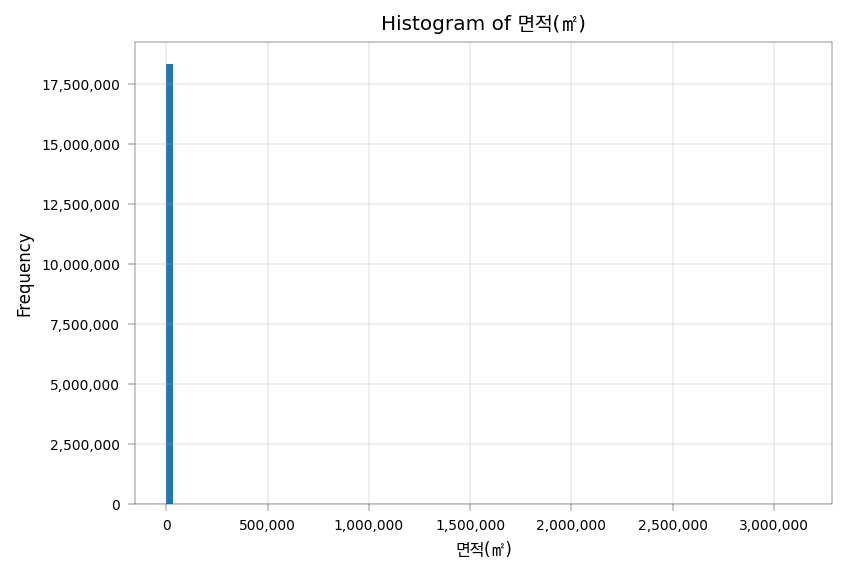

In [31]:
def plot_histogram(df, value_column, bins=100):
    """
    면적(㎡) 값을 100개의 구간으로 나누어 히스토그램을 그리는 함수.

    Parameters:
    df (dask.dataframe.DataFrame): 분석할 pandas
    
    value_column (str): 히스토그램을 그릴 값의 열 이름.
    bins (int): 히스토그램의 구간 개수 (기본값: 100).

    Returns:
    None
    """
    
    # 연면적(㎡) 값을 히스토그램으로 그리기
    ## plt.figure(figsize=(10, 6))
    ## plt.hist(df[value_column], bins=bins, color='skyblue', edgecolor='black')
    plt.figure()
    plt.hist(df[value_column], bins=bins)
    plt.title('Histogram of 면적(㎡)')
    plt.xlabel('면적(㎡)')
    plt.ylabel('Frequency')
    plt.grid(True)
    # Set the format of tick labels to non-scientific
    plt.ticklabel_format(style='plain', useOffset=False)
    # Format the tick labels with commas for thousands
    formatter = ticker.StrMethodFormatter('{x:,.0f}') # This formats the number with commas
    plt.gca().xaxis.set_major_formatter(formatter)
    plt.gca().yaxis.set_major_formatter(formatter)
    plt.show()

# 사용 예시
plot_histogram(filtered_joined_ddf, '면적(㎡)', bins=100)

이상치가 미치는 전체 데이터의 영향을 확인하기 위하여 면적의 상위값을 0.1%~15%까지 1%씩 가중하여 히스토그램 그림.

In [32]:
# 면적(㎡) 칼럼에 상용로그를 취하여 새로운 컬럼으로 저장
filtered_joined_ddf['상용로그_면적'] = np.log10(filtered_joined_ddf['면적(㎡)'])

In [33]:
filtered_joined_ddf['상용로그_면적'].dtype

dtype('float64')

In [34]:
with pd.option_context('display.float_format', '{:,.3f}'.format):
    display(filtered_joined_ddf['상용로그_면적'].describe())

count   18,334,368.000
mean             2.013
std              0.508
min             -4.000
25%              1.701
50%              1.989
75%              2.332
max              6.496
Name: 상용로그_면적, dtype: float64

In [30]:
with pd.option_context('display.float_format', '{:,.6f}'.format):
    display(filtered_joined_ddf['면적(㎡)'].describe())

count   18,334,368.000000
mean           212.501803
std            949.384304
min              0.000100
25%             50.200000
50%             97.580000
75%            214.620000
max      3,131,783.000000
Name: 면적(㎡), dtype: float64

In [35]:
with pd.option_context('display.float_format', '{:,.3f}'.format):
    display(filtered_joined_ddf.head())


,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,...,대지_면적(㎡),건축_면적(㎡),연면적(㎡),구조_코드_dong,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year,상용로그_면적
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,
0-2998,20,지상,1,1층,21,철근콘크리트구조,철골조,17100,일반공장,공장,...,"59,450.700","31,616.080","32,985.480",31,17000,공장,"32,985.480",1998,True,4.490
0-2998,10,지하,1,지1,21,철근콘크리트구조,철근콘크리트조,17100,일반공장,기계실,...,"59,450.700","31,616.080","32,985.480",31,17000,공장,"32,985.480",1998,True,3.137
11110-1000,10,지하,1,지하층,11,벽돌구조,조적조,02002,연립주택,"보일러실,대피실,지하계단실",...,0.000,0.000,"1,151.910",11,02000,연립주택,"1,151.910",1986,True,2.210
11110-1000,20,지상,1,1층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,0.000,0.000,"1,151.910",11,02000,연립주택,"1,151.910",1986,True,2.588
11110-1000,20,지상,2,2층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,0.000,0.000,"1,151.910",11,02000,연립주택,"1,151.910",1986,True,2.582


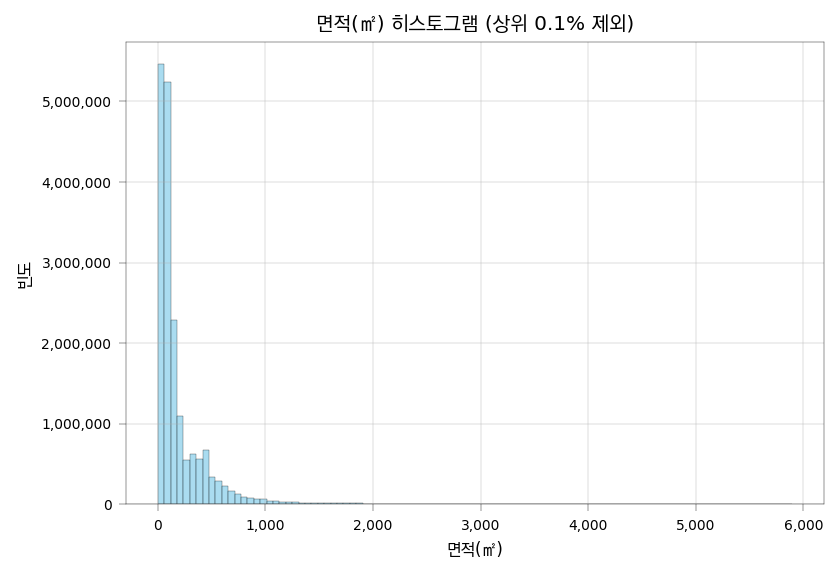

In [36]:
def plot_area_histogram(df):
    # 면적(㎡) 칼럼의 상위 0.1%를 제외한 데이터 추출
    quantile_999 = df['면적(㎡)'].quantile(0.999)
    filtered_df = df[df['면적(㎡)'] <= quantile_999]

    # 100개의 구간으로 나누기
    bins = np.linspace(filtered_df['면적(㎡)'].min(), filtered_df['면적(㎡)'].max(), 100)

    # 히스토그램 그리기
    plt.hist(filtered_df['면적(㎡)'], bins=bins, color='skyblue', edgecolor='black', alpha=0.7)
    plt.xlabel('면적(㎡)')
    plt.ylabel('빈도')
    plt.title('면적(㎡) 히스토그램 (상위 0.1% 제외)')
    plt.grid(True)
    # Set the format of tick labels to non-scientific
    plt.ticklabel_format(style='plain', useOffset=False)
    # Format the tick labels with commas for thousands
    formatter = ticker.StrMethodFormatter('{x:,.0f}') # This formats the number with commas
    plt.gca().xaxis.set_major_formatter(formatter)
    plt.gca().yaxis.set_major_formatter(formatter)
    plt.show()


# 사용 예시
plot_area_histogram(filtered_joined_ddf)


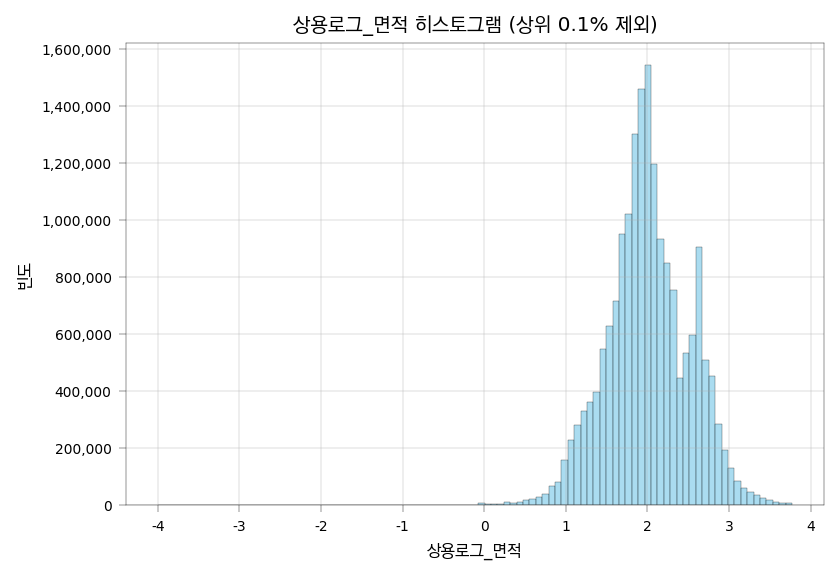

In [37]:
def plot_area_histogram(df, column_name):
    # 면적(㎡) 칼럼의 상위 0.1%를 제외한 데이터 추출
    quantile_999 = df[column_name].quantile(0.999)
    filtered_df = df[df[column_name] <= quantile_999]

    # 100개의 구간으로 나누기
    bins = np.linspace(filtered_df[column_name].min(), filtered_df[column_name].max(), 100)

    # 히스토그램 그리기
    plt.hist(filtered_df[column_name], bins=bins, color='skyblue', edgecolor='black', alpha=0.7)
    plt.xlabel(column_name)
    plt.ylabel('빈도')
    plt.title(f'{column_name} 히스토그램 (상위 0.1% 제외)')
    plt.grid(True)
    # Set the format of tick labels to non-scientific
    plt.ticklabel_format(style='plain', useOffset=False)
    # Format the tick labels with commas for thousands
    formatter = ticker.StrMethodFormatter('{x:,.0f}') # This formats the number with commas
    plt.gca().xaxis.set_major_formatter(formatter)
    plt.gca().yaxis.set_major_formatter(formatter)
    plt.show()


# 사용 예시
plot_area_histogram(filtered_joined_ddf,'상용로그_면적')


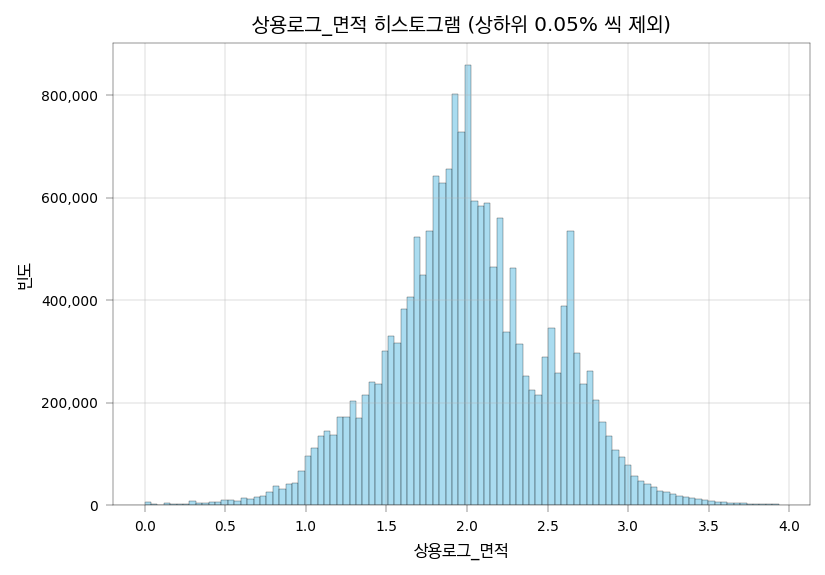

In [38]:
def plot_area_histogram(df, column_name):
    # 면적(㎡) 칼럼의 상하위 0.05% 씩을 제외한 데이터 추출
    quantile_low = df[column_name].quantile(0.0005)
    quantile_high = df[column_name].quantile(0.9995)
    filtered_df = df[(df[column_name] >= quantile_low) & (df[column_name] <= quantile_high)]

    # 100개의 구간으로 나누기
    bins = np.linspace(filtered_df[column_name].min(), filtered_df[column_name].max(), 100)

    # 히스토그램 그리기
    plt.hist(filtered_df[column_name], bins=bins, color='skyblue', edgecolor='black', alpha=0.7)
    plt.xlabel(column_name)
    plt.ylabel('빈도')
    plt.title(f'{column_name} 히스토그램 (상하위 0.05% 씩 제외)')
    plt.grid(True)
    # Set the format of tick labels to non-scientific
    plt.ticklabel_format(style='plain', useOffset=False)
    # Format the tick labels with commas for thousands
    formatter = ticker.StrMethodFormatter('{x:,.0f}') # This formats the number with commas
    # plt.gca().xaxis.set_major_formatter(formatter)
    plt.gca().yaxis.set_major_formatter(formatter)
    plt.show()


# 사용 예시
plot_area_histogram(filtered_joined_ddf,'상용로그_면적')


상용로그_면적의 상하위 0.05% 이내의 값을 새로운 컬럼을 추가하여 표시

In [39]:
# filtered_joined_ddf에서 '상용로그_면적' 칼럼의 상위 및 하위 0.05% 값을 계산합니다.
upper_threshold = filtered_joined_ddf['상용로그_면적'].quantile(0.9995)  # 상위 0.05%
lower_threshold = filtered_joined_ddf['상용로그_면적'].quantile(0.0005)  # 하위 0.05%

# 'Upper_lower' 칼럼에 조건에 따라 상위/하위/일반을 지정합니다.
filtered_joined_ddf['Upper_lower'] = '일반'
filtered_joined_ddf.loc[filtered_joined_ddf['상용로그_면적'] > upper_threshold, 'Upper_lower'] = '상위'
filtered_joined_ddf.loc[filtered_joined_ddf['상용로그_면적'] < lower_threshold, 'Upper_lower'] = '하위'

# 결과를 확인합니다.
filtered_joined_ddf.head()

,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,...,건축_면적(㎡),연면적(㎡),구조_코드_dong,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year,상용로그_면적,Upper_lower
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,
0-2998,20,지상,1,1층,21,철근콘크리트구조,철골조,17100,일반공장,공장,...,"31,616","32,985",31,17000,공장,"32,985",1998,True,4,상위
0-2998,10,지하,1,지1,21,철근콘크리트구조,철근콘크리트조,17100,일반공장,기계실,...,"31,616","32,985",31,17000,공장,"32,985",1998,True,3,일반
11110-1000,10,지하,1,지하층,11,벽돌구조,조적조,02002,연립주택,"보일러실,대피실,지하계단실",...,0,"1,152",11,02000,연립주택,"1,152",1986,True,2,일반
11110-1000,20,지상,1,1층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,0,"1,152",11,02000,연립주택,"1,152",1986,True,3,일반
11110-1000,20,지상,2,2층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,0,"1,152",11,02000,연립주택,"1,152",1986,True,3,일반


In [40]:
filtered_joined_ddf.Upper_lower.value_counts()

일반    18321593
상위        9168
하위        3607
Name: Upper_lower, dtype: int64

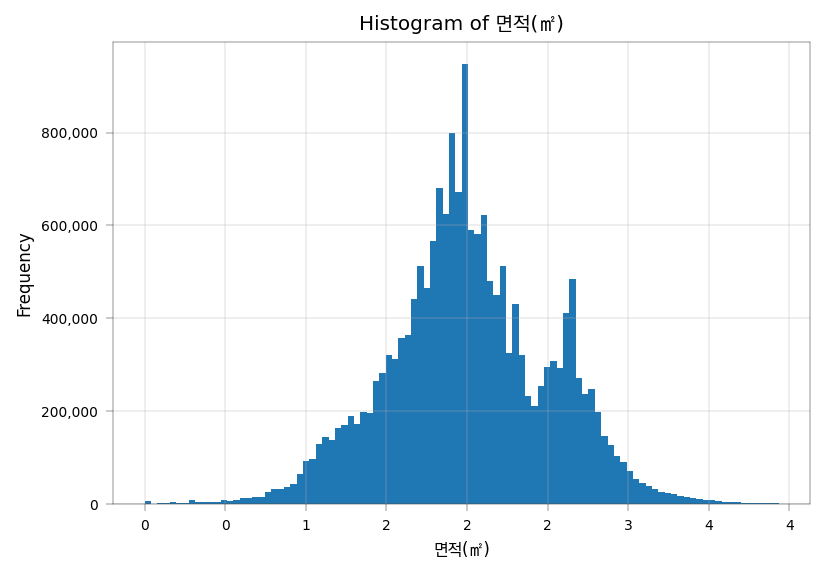

In [41]:
plot_histogram(filtered_joined_ddf[filtered_joined_ddf['Upper_lower'] =='일반'], '상용로그_면적', bins=100)

In [105]:
with pd.option_context("display.max_rows", None, "display.max_columns", 100):
    # display(filtered_joined_ddf[filtered_joined_ddf['Upper_lower'] == '일반'].nlargest(1, '면적(㎡)'))
    display(filtered_joined_ddf[filtered_joined_ddf['Upper_lower'] == '일반'].nsmallest(1, '면적(㎡)'))


,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,면적(㎡),주_부속_구분_코드,면적_제외_여부,생성_일자,시군구_코드,법정동_코드,주_부속_구분_코드_dong,대지_면적(㎡),건축_면적(㎡),연면적(㎡),구조_코드_dong,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year,상용로그_면적,Upper_lower
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,,,,,,,,
11110-11121,10,지하,1,지1층,21,철근콘크리트구조,철근콘크리트조,03999,기타제1종근린생활시설,<NA>,1,0,<NA>,20180914,11110,14100,0,627,272,"1,212",21,03000,근린생활시설,"1,212",1986,True,0,일반


통계용 최종 데이터 프레임 완성!

In [42]:
f_df = filtered_joined_ddf[filtered_joined_ddf['Upper_lower'] == '일반']

In [43]:
f_df['면적(㎡)'].describe()

count   18,321,593
mean           205
std            359
min              1
25%             50
50%             98
75%            214
max          8,599
Name: 면적(㎡), dtype: float64

층별개요의 주_용도_코드는 세부용도를 기준으로 수록되어 있으며, 행정표준코드관리시스템에는 759개의 용도 코드가 있고, 현행 사용중인 코드는 5자리 534개이며, 2009년 일괄 개정되어 4자리 기존코드는 225개가 있음. 데이터 상으로는 698개가 있고, 코드 오기는 2개 층이 문자로 입력되어 오기로 확인.
주택 코드를 시리즈로 저장하고 이와 비교하여 각 층의 주택여부를 최종 데이터에 컬럼을 추가하여 표기

In [44]:
with pd.option_context("display.max_rows", None, "display.max_columns", 100):
    display(f_df.주_용도_코드.value_counts())

01001    4954471
02001    2688101
01003    1893799
02003    1254002
03001     845569
04402     563837
04001     528504
18001     390046
21101     383661
17100     370943
03999     303884
17999     227559
04999     201687
14202     196449
04005     178433
02002     152072
21999     118826
03002     110080
03005     108334
02005     104189
04010     103463
18999     102959
15102      86137
04499      84309
01002      78999
14204      78832
18101      75328
17301      60924
14299      60905
11201      59340
06101      54417
20001      54078
04006      46286
03021      46066
10101      44388
03011      41250
03199      36841
10104      32680
10999      30296
10003      30129
04002      29529
23003      29061
10103      28601
15199      27697
19001      26433
04035      25754
03007      25483
04201      24308
15002      22510
17200      22024
09107      21698
03003      20427
16002      20376
03027      20339
10102      20085
20006      19894
11103      19520
04020      19409
02004      193

In [42]:
with pd.option_context("display.max_rows", None, "display.max_columns", 100):
    display(f_df[f_df['주_용도_코드'] == 'b0299'].head())

,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,면적(㎡),주_부속_구분_코드,면적_제외_여부,생성_일자,시군구_코드,법정동_코드,주_부속_구분_코드_dong,대지_면적(㎡),건축_면적(㎡),연면적(㎡),구조_코드_dong,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year,상용로그_면적,Upper_lower
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,,,,,,,,
26110-2984,20,지상,3,3,21,철근콘크리트구조,철근콘크리트조,b0299,<NA>,사무실,114,0,<NA>,20200427,26110,10600,0,143,114,574,21,03000,"점포, 사무실 , 단독주택",574,1975,True,2,일반
26110-3380,20,지상,3,3,42,철골철근콘크리트구조,철골철근콘크리트,b0299,<NA>,업무시설,453,0,<NA>,20200228,26110,10700,0,739,585,"9,468",42,14000,"업무시설, 근린생활시설","9,468",1997,True,3,일반
26110-3380,20,지상,6,6,42,철골철근콘크리트구조,철골철근콘크리트,b0299,<NA>,업무시설,528,0,<NA>,20200228,26110,10700,0,739,585,"9,468",42,14000,"업무시설, 근린생활시설","9,468",1997,True,3,일반
26110-3380,20,지상,12,12,42,철골철근콘크리트구조,철골철근콘크리트,b0299,<NA>,업무시설,584,0,<NA>,20200228,26110,10700,0,739,585,"9,468",42,14000,"업무시설, 근린생활시설","9,468",1997,True,3,일반
26110-3380,20,지상,5,5,42,철골철근콘크리트구조,철골철근콘크리트,b0299,<NA>,업무시설,528,0,<NA>,20200228,26110,10700,0,739,585,"9,468",42,14000,"업무시설, 근린생활시설","9,468",1997,True,3,일반


In [45]:
h_list = [
    '01000', '01001', '01002', '01003', '01004', '01005', '01006', '01007', '01008', '02000', '02001', '02002', '02003', '02004', '02005', '02006', '02007', '02008', '02009', '02010', '02011',
    '1000', '1002', '1003', '1004', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007']
h_list

['01000',
 '01001',
 '01002',
 '01003',
 '01004',
 '01005',
 '01006',
 '01007',
 '01008',
 '02000',
 '02001',
 '02002',
 '02003',
 '02004',
 '02005',
 '02006',
 '02007',
 '02008',
 '02009',
 '02010',
 '02011',
 '1000',
 '1002',
 '1003',
 '1004',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007']

In [46]:
f_df['housing'] = f_df['주_용도_코드'].isin(h_list)
f_df.head()

C:\Users\user\AppData\Local\Temp\ipykernel_20600\4022778981.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f_df['housing'] = f_df['주_용도_코드'].isin(h_list)


,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,...,연면적(㎡),구조_코드_dong,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year,상용로그_면적,Upper_lower,housing
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,
0-2998,10,지하,1,지1,21,철근콘크리트구조,철근콘크리트조,17100,일반공장,기계실,...,"32,985",31,17000,공장,"32,985",1998,True,3,일반,False
11110-1000,10,지하,1,지하층,11,벽돌구조,조적조,02002,연립주택,"보일러실,대피실,지하계단실",...,"1,152",11,02000,연립주택,"1,152",1986,True,2,일반,True
11110-1000,20,지상,1,1층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,"1,152",11,02000,연립주택,"1,152",1986,True,3,일반,True
11110-1000,20,지상,2,2층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,"1,152",11,02000,연립주택,"1,152",1986,True,3,일반,True
11110-1000,20,지상,3,3층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,"1,152",11,02000,연립주택,"1,152",1986,True,2,일반,True


주거용도의 층수는 11178188이고, 전체면적은 1919665783.922038이며, 층별 평균은 171.7331810774732d임. 비주거용도의 층수는 7143405이며, 전체면적은 1828998666.49204이며, 층별 평균은 256.040175027461임.

In [47]:
f_df.housing.value_counts()

True     11178188
False     7143405
Name: housing, dtype: int64

In [55]:
f_df[f_df['housing']]['면적(㎡)'].sum()

1919665783.922038

In [56]:
f_df[f_df['housing']]['면적(㎡)'].mean()

171.7331810774732

In [57]:
f_df[~f_df['housing']]['면적(㎡)'].sum()

1828998666.49204

In [58]:
f_df[~f_df['housing']]['면적(㎡)'].mean()

256.040175027461

각 층을 가중치로 우리나라 건축물의 평균 사용승인년도는 1996.5976228158763이며, 24년 6월 기준 평균연령은 27.90237718412368세이다.
면적을 기준으로 우리나라 건축물의 평균 사용승인년도는  2003.2695815091042이며, 24년 6월 기준 평균연령은 21.230418490895772세이다.

면적 기준으로 주거용/비주거용을 살펴보면,면적기준 주거용도 사용승인연도 평균: 2002.317742587773 평균연령 22.182257412227045이며, 면적기준 비주거용도 사용승인연도 평균: 2004.2674693014803 평균연령 20.232530698519668

In [48]:
2024.5 - f_df['year'].astype(int).mean()

27.90237718412368

In [49]:
def weighted_avg(ddf_x):
    weights = ddf_x['면적(㎡)']  # 면적을 가중치로 사용
    values = ddf_x['year'].astype(int)
    weighted_sum = (values*weights).sum()
    sum_of_weights = weights.sum()
    return weighted_sum /sum_of_weights

# year 컬럼의 가중평균 계산
weighted_average_year = weighted_avg(f_df)

print("면적기준 year 가중평균:", weighted_average_year, "평균연령", 2024.5 - weighted_average_year)

면적기준 year 가중평균: 2003.2547622331524 평균연령 21.245237766847595


In [50]:
# 'housing' 컬럼이 True인 행들을 선택합니다.
housing_true_df = f_df[f_df['housing']]

# 면적과 연도를 각각 가져옵니다.
area_values = housing_true_df['면적(㎡)']
year_values = housing_true_df['year'].astype(int)

# 면적을 가중치로 사용하여 가중평균을 계산합니다.
weighted_sum = (area_values * year_values).sum()
total_area = area_values.sum()
weighted_average = weighted_sum / total_area

print("면적기준 주거용도 사용승인연도 평균:", weighted_average, "평균연령", 2024.5 - weighted_average)

면적기준 주거용도 사용승인연도 평균: 2002.298241261257 평균연령 22.20175873874291


In [51]:
# 'housing' 컬럼이 false인 행들을 선택합니다.
housing_false_df = f_df[~f_df['housing']]

# 면적과 연도를 각각 가져옵니다.
area_values = housing_false_df['면적(㎡)']
year_values = housing_false_df['year'].astype(int)

# 면적을 가중치로 사용하여 가중평균을 계산합니다.
weighted_sum = (area_values * year_values).sum()
total_area = area_values.sum()
weighted_average = weighted_sum / total_area

print("면적기준 비주거용도 사용승인연도 평균:", weighted_average, "평균연령", 2024.5 - weighted_average)

면적기준 비주거용도 사용승인연도 평균: 2004.2586998603322 평균연령 20.24130013966783


층별 연령대 구간(5년단위) bin컬럼에 추가

In [52]:
# 1924년부터 2023년까지의 연도 범위 생성
years_range = list(range(1923, 2024))

# 구간을 담을 리스트 초기화
bins = []

# 1924년 이전을 하나의 구간으로 통합
bins.append(-1)

# 5년 단위로 구간을 나누기
for year in range(1923, 2024, 5):
    bins.append(year)

# 리스트 출력
print(bins)

[-1, 1923, 1928, 1933, 1938, 1943, 1948, 1953, 1958, 1963, 1968, 1973, 1978, 1983, 1988, 1993, 1998, 2003, 2008, 2013, 2018, 2023]


In [117]:
len(bins)

22

In [53]:
# 0세부터 100세 이상까지의 연령대 구간 리스트 생성
age_ranges = list(f"{y-5}-{y-1}년" for y in range(105, 0, -5))

# 마지막 구간을 100세 이상으로 변경
age_ranges[0] = '100년 이상'

# 결과 출력
print(age_ranges)


['100년 이상', '95-99년', '90-94년', '85-89년', '80-84년', '75-79년', '70-74년', '65-69년', '60-64년', '55-59년', '50-54년', '45-49년', '40-44년', '35-39년', '30-34년', '25-29년', '20-24년', '15-19년', '10-14년', '5-9년', '0-4년']


In [107]:
len(age_ranges)

21

In [54]:
f_df['bin'] = pd.cut(f_df['year'].astype(int), bins=bins, labels=age_ranges)
f_df.head()

C:\Users\user\AppData\Local\Temp\ipykernel_20600\2308196789.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f_df['bin'] = pd.cut(f_df['year'].astype(int), bins=bins, labels=age_ranges)


,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,...,구조_코드_dong,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year,상용로그_면적,Upper_lower,housing,bin
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,
0-2998,10,지하,1,지1,21,철근콘크리트구조,철근콘크리트조,17100,일반공장,기계실,...,31,17000,공장,"32,985",1998,True,3,일반,False,25-29년
11110-1000,10,지하,1,지하층,11,벽돌구조,조적조,02002,연립주택,"보일러실,대피실,지하계단실",...,11,02000,연립주택,"1,152",1986,True,2,일반,True,35-39년
11110-1000,20,지상,1,1층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,11,02000,연립주택,"1,152",1986,True,3,일반,True,35-39년
11110-1000,20,지상,2,2층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,11,02000,연립주택,"1,152",1986,True,3,일반,True,35-39년
11110-1000,20,지상,3,3층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,11,02000,연립주택,"1,152",1986,True,2,일반,True,35-39년


시군구별 주거, 비주거 충수와 면적 산출하여 CSV로 저장

In [55]:
pd.options.display.float_format = '{:,.0f}'.format

# result = ddf_new.groupby('bin')['연면적(㎡)'].sum().compute()
result = f_df.groupby(['시군구_코드','bin','housing']).agg({'면적(㎡)': ['count', 'sum']})

result

면적(㎡)        
                                  count     sum
시군구_코드 bin        housing                 
0           100년 이상 False          0       0
                       True           0       0
            95-99년    False          0       0
                       True           0       0
            90-94년    False          0       0
...                                 ...     ...
51830       10-14년    True         928  65,387
            5-9년      False       1258 185,121
                       True        1681 183,662
            0-4년      False       1701 337,496
                       True        1641 199,821

[10710 rows x 2 columns]

In [56]:
result.index

MultiIndex([(    '0', '100년 이상', False),
            (    '0', '100년 이상',  True),
            (    '0',  '95-99년', False),
            (    '0',  '95-99년',  True),
            (    '0',  '90-94년', False),
            (    '0',  '90-94년',  True),
            (    '0',  '85-89년', False),
            (    '0',  '85-89년',  True),
            (    '0',  '80-84년', False),
            (    '0',  '80-84년',  True),
            ...
            ('51830',  '20-24년', False),
            ('51830',  '20-24년',  True),
            ('51830',  '15-19년', False),
            ('51830',  '15-19년',  True),
            ('51830',  '10-14년', False),
            ('51830',  '10-14년',  True),
            ('51830',    '5-9년', False),
            ('51830',    '5-9년',  True),
            ('51830',    '0-4년', False),
            ('51830',    '0-4년',  True)],
           names=['시군구_코드', 'bin', 'housing'], length=10710)

In [57]:
df_sgg_name = pd.read_csv("data/code_sgg.csv", dtype=str)
df_sgg_name = df_sgg_name.set_index("시군구코드")
s_sgg = df_sgg_name.시군구명
s_sgg = s_sgg.rename_axis('시군구_코드')
s_sgg

시군구_코드
11000               서울특별시
11110        서울특별시 종로구
11140          서울특별시 중구
11170        서울특별시 용산구
11200        서울특별시 성동구
                 ...          
52740    전북특별자치도 장수군
52750    전북특별자치도 임실군
52770    전북특별자치도 순창군
52790    전북특별자치도 고창군
52800    전북특별자치도 부안군
Name: 시군구명, Length: 501, dtype: object

In [58]:
# Column name to remove
column_to_remove = s_sgg.name

# Check if the column exists before removing it
if column_to_remove in result.columns:
    result.drop(column_to_remove, axis=1, inplace=True)

result = result.join(s_sgg)
result

C:\Users\user\AppData\Local\Temp\ipykernel_20600\4056329173.py:8: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (2 levels on the left, 1 on the right)
  result = result.join(s_sgg)


(면적(㎡), count)  (면적(㎡), sum)  \
시군구_코드 bin        housing                                       
0           100년 이상 False                    0                0   
                       True                     0                0   
            95-99년    False                    0                0   
                       True                     0                0   
            90-94년    False                    0                0   
...                                           ...              ...   
51830       10-14년    True                   928           65,387   
            5-9년      False                 1258          185,121   
                       True                  1681          183,662   
            0-4년      False                 1701          337,496   
                       True                  1641          199,821   

                                             시군구명  
시군구_코드 bin        housing                         
0           100년 이상 False                      NaN  
                       True                       NaN  
            95-99년    False                      NaN  
                       True                       NaN  
            90-94년    False                      NaN  
...                                               ...  
51830       10-14년    True     강원특별자치도 양양군  
            5-9년      False    강원특별자치도 양양군  
                       True     강원특별자치도 양양군  
            0-4년      False    강원특별자치도 양양군  
                       True     강원특별자치도 양양군  

[10710 rows x 3 columns]

In [77]:
result.join(s_sgg).to_csv('output/층별_연령_시군구.csv', encoding='utf-8-sig')

C:\Users\user\AppData\Local\Temp\ipykernel_10372\981891025.py:1: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (2 levels on the left, 1 on the right)
  result.join(s_sgg).to_csv('output/층별_연령_시군구.csv', encoding='utf-8-sig')


In [59]:
f_df.columns

Index(['층_구분_코드', '층_구분_코드_명', '층_번호', '층_번호_명', '구조_코드',
       '구조_코드_명', '기타_구조', '주_용도_코드', '주_용도_코드_명',
       '기타_용도', '면적(㎡)', '주_부속_구분_코드', '면적_제외_여부',
       '생성_일자', '시군구_코드', '법정동_코드', '주_부속_구분_코드_dong',
       '대지_면적(㎡)', '건축_면적(㎡)', '연면적(㎡)', '구조_코드_dong',
       '주_용도_코드_dong', '기타_용도_dong', '총_동_연면적(㎡)', 'year',
       'T_year', '상용로그_면적', 'Upper_lower', 'housing', 'bin'],
      dtype='object')

In [60]:
df_sggcode = f_df[['시군구_코드','bin','housing']].reset_index()
unique_counts = df_sggcode.groupby(['시군구_코드','bin','housing'])['관리_건축물대장_PK'].nunique()
unique_counts.name = '동_수'
unique_counts

시군구_코드  bin         housing
0            100년 이상  False         0
                         True          0
             95-99년     False         0
                         True          0
             90-94년     False         0
                                    ... 
51830        10-14년     True        599
             5-9년       False       810
                         True        952
             0-4년       False      1021
                         True        845
Name: 동_수, Length: 10710, dtype: int64

In [61]:
unique_counts.sum()

7826298

In [62]:
# Column name to remove
column_to_remove = unique_counts.name

# Check if the column exists before removing it
if column_to_remove in result.columns:
    result.drop(column_to_remove, axis=1, inplace=True)

result = result.join(unique_counts)
result

(면적(㎡), count)  (면적(㎡), sum)  \
시군구_코드 bin        housing                                       
0           100년 이상 False                    0                0   
                       True                     0                0   
            95-99년    False                    0                0   
                       True                     0                0   
            90-94년    False                    0                0   
...                                           ...              ...   
51830       10-14년    True                   928           65,387   
            5-9년      False                 1258          185,121   
                       True                  1681          183,662   
            0-4년      False                 1701          337,496   
                       True                  1641          199,821   

                                             시군구명  동_수  
시군구_코드 bin        housing                                
0           100년 이상 False                      NaN      0  
                       True                       NaN      0  
            95-99년    False                      NaN      0  
                       True                       NaN      0  
            90-94년    False                      NaN      0  
...                                               ...    ...  
51830       10-14년    True     강원특별자치도 양양군    599  
            5-9년      False    강원특별자치도 양양군    810  
                       True     강원특별자치도 양양군    952  
            0-4년      False    강원특별자치도 양양군   1021  
                       True     강원특별자치도 양양군    845  

[10710 rows x 4 columns]

In [97]:
result.to_csv('output/동별_층별_연령_시군구.csv', encoding='utf-8-sig')

층별 연령대 구간(1년단위) bin2컬럼에 추가

In [63]:
# 1924년부터 2023년까지의 연도 범위 생성
years_range = list(range(1923, 2024))

# 구간을 담을 리스트 초기화
bins2 = []

# 1924년 이전을 하나의 구간으로 통합
bins2.append(-1)

# 5년 단위로 구간을 나누기
for year in range(1923, 2024, 1):
    bins2.append(year)

# 리스트 출력
print(bins2)

[-1, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


In [64]:
len(bins2)

102

In [65]:
# 0세부터 100세 이상까지의 연령대 구간 리스트 생성
age_ranges2 = list(f"{y-1}년" for y in range(101, 0, -1))

# 마지막 구간을 100세 이상으로 변경
age_ranges2[0] = '100년 이상'

# 결과 출력
print(age_ranges2)


['100년 이상', '99년', '98년', '97년', '96년', '95년', '94년', '93년', '92년', '91년', '90년', '89년', '88년', '87년', '86년', '85년', '84년', '83년', '82년', '81년', '80년', '79년', '78년', '77년', '76년', '75년', '74년', '73년', '72년', '71년', '70년', '69년', '68년', '67년', '66년', '65년', '64년', '63년', '62년', '61년', '60년', '59년', '58년', '57년', '56년', '55년', '54년', '53년', '52년', '51년', '50년', '49년', '48년', '47년', '46년', '45년', '44년', '43년', '42년', '41년', '40년', '39년', '38년', '37년', '36년', '35년', '34년', '33년', '32년', '31년', '30년', '29년', '28년', '27년', '26년', '25년', '24년', '23년', '22년', '21년', '20년', '19년', '18년', '17년', '16년', '15년', '14년', '13년', '12년', '11년', '10년', '9년', '8년', '7년', '6년', '5년', '4년', '3년', '2년', '1년', '0년']


In [66]:
len(age_ranges2)

101

In [67]:
f_df['bin2'] = pd.cut(f_df['year'].astype(int), bins=bins2, labels=age_ranges2)
f_df.head()

C:\Users\user\AppData\Local\Temp\ipykernel_20600\1136888355.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f_df['bin2'] = pd.cut(f_df['year'].astype(int), bins=bins2, labels=age_ranges2)


,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,...,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year,상용로그_면적,Upper_lower,housing,bin,bin2
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,
0-2998,10,지하,1,지1,21,철근콘크리트구조,철근콘크리트조,17100,일반공장,기계실,...,17000,공장,"32,985",1998,True,3,일반,False,25-29년,25년
11110-1000,10,지하,1,지하층,11,벽돌구조,조적조,02002,연립주택,"보일러실,대피실,지하계단실",...,02000,연립주택,"1,152",1986,True,2,일반,True,35-39년,37년
11110-1000,20,지상,1,1층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,02000,연립주택,"1,152",1986,True,3,일반,True,35-39년,37년
11110-1000,20,지상,2,2층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,02000,연립주택,"1,152",1986,True,3,일반,True,35-39년,37년
11110-1000,20,지상,3,3층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,02000,연립주택,"1,152",1986,True,2,일반,True,35-39년,37년


bin2를 기준으로 시군구별로 데이터 합산하여 CSV파일로 출력

In [68]:
pd.options.display.float_format = '{:,.0f}'.format

# result = ddf_new.groupby('bin')['연면적(㎡)'].sum().compute()
result2 = f_df.groupby(['시군구_코드','bin2','housing']).agg({'면적(㎡)': ['count', 'sum']})

result2

면적(㎡)       
                                  count    sum
시군구_코드 bin2       housing                
0           100년 이상 False          0      0
                       True           0      0
            99년       False          0      0
                       True           0      0
            98년       False          0      0
...                                 ...    ...
51830       2년        True         268 18,885
            1년        False        333 60,353
                       True         283 20,644
            0년        False        391 83,786
                       True         316 23,902

[51510 rows x 2 columns]

In [69]:
# Column name to remove
column_to_remove = s_sgg.name

# Check if the column exists before removing it
if column_to_remove in result2.columns:
    result2.drop(column_to_remove, axis=1, inplace=True)

result2 = result2.join(s_sgg)
result2

C:\Users\user\AppData\Local\Temp\ipykernel_20600\1304964037.py:8: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (2 levels on the left, 1 on the right)
  result2 = result2.join(s_sgg)


(면적(㎡), count)  (면적(㎡), sum)  \
시군구_코드 bin2       housing                                       
0           100년 이상 False                    0                0   
                       True                     0                0   
            99년       False                    0                0   
                       True                     0                0   
            98년       False                    0                0   
...                                           ...              ...   
51830       2년        True                   268           18,885   
            1년        False                  333           60,353   
                       True                   283           20,644   
            0년        False                  391           83,786   
                       True                   316           23,902   

                                             시군구명  
시군구_코드 bin2       housing                         
0           100년 이상 False                      NaN  
                       True                       NaN  
            99년       False                      NaN  
                       True                       NaN  
            98년       False                      NaN  
...                                               ...  
51830       2년        True     강원특별자치도 양양군  
            1년        False    강원특별자치도 양양군  
                       True     강원특별자치도 양양군  
            0년        False    강원특별자치도 양양군  
                       True     강원특별자치도 양양군  

[51510 rows x 3 columns]

In [70]:
df_sggcode = f_df[['시군구_코드','bin2','housing']].reset_index()
unique_counts2 = df_sggcode.groupby(['시군구_코드','bin2','housing'])['관리_건축물대장_PK'].nunique()
unique_counts2.name = '동_수'
unique_counts2

시군구_코드  bin2        housing
0            100년 이상  False        0
                         True         0
             99년        False        0
                         True         0
             98년        False        0
                                   ... 
51830        2년         True       174
             1년         False      184
                         True       166
             0년         False      210
                         True       173
Name: 동_수, Length: 51510, dtype: int64

In [71]:
# Column name to remove
column_to_remove = unique_counts2.name

# Check if the column exists before removing it
if column_to_remove in result2.columns:
    result2.drop(column_to_remove, axis=1, inplace=True)

result2 = result2.join(unique_counts2)
result2

(면적(㎡), count)  (면적(㎡), sum)  \
시군구_코드 bin2       housing                                       
0           100년 이상 False                    0                0   
                       True                     0                0   
            99년       False                    0                0   
                       True                     0                0   
            98년       False                    0                0   
...                                           ...              ...   
51830       2년        True                   268           18,885   
            1년        False                  333           60,353   
                       True                   283           20,644   
            0년        False                  391           83,786   
                       True                   316           23,902   

                                             시군구명  동_수  
시군구_코드 bin2       housing                                
0           100년 이상 False                      NaN      0  
                       True                       NaN      0  
            99년       False                      NaN      0  
                       True                       NaN      0  
            98년       False                      NaN      0  
...                                               ...    ...  
51830       2년        True     강원특별자치도 양양군    174  
            1년        False    강원특별자치도 양양군    184  
                       True     강원특별자치도 양양군    166  
            0년        False    강원특별자치도 양양군    210  
                       True     강원특별자치도 양양군    173  

[51510 rows x 4 columns]

In [131]:
result2.to_csv('output/동별_층별_1년단위_연령_시군구.csv', encoding='utf-8-sig')

면적기준 사용승인연도 주거/비주거 전국, 광역, 기초
로그면적기준 사용승인연도 주거/비주거 전국, 광역, 기초

In [72]:
def weighted_avg(ddf_x):
    weights = ddf_x['상용로그_면적']  # 면적을 가중치로 사용
    values = ddf_x['year'].astype(int)
    weighted_sum = (values*weights).sum()
    sum_of_weights = weights.sum()
    return weighted_sum /sum_of_weights

# year 컬럼의 가중평균 계산
weighted_average_year = weighted_avg(f_df)

print("상용로그_면적 기준 year 가중평균:", weighted_average_year, "평균연령", 2024.5 - weighted_average_year)

상용로그_면적 기준 year 가중평균: 1998.4109753910104 평균연령 26.089024608989575


In [73]:
# 'housing' 컬럼이 True인 행들을 선택합니다.
housing_true_df = f_df[f_df['housing']]

# 면적과 연도를 각각 가져옵니다.
area_values = housing_true_df['상용로그_면적']
year_values = housing_true_df['year'].astype(int)

# 면적을 가중치로 사용하여 가중평균을 계산합니다.
weighted_sum = (area_values * year_values).sum()
total_area = area_values.sum()
weighted_average = weighted_sum / total_area

print("상용로그_면적 기준 주거용도 사용승인연도 평균:", weighted_average, "평균연령", 2024.5 - weighted_average)

상용로그_면적 기준 주거용도 사용승인연도 평균: 1996.9429389800014 평균연령 27.557061019998628


In [74]:
# 시군구_코드별로 면적을 가중치로 하여 year의 평균 계산
weighted_mean_by_year = f_df.groupby('시군구_코드').apply(lambda x: pd.np.average(x['year'].astype(np.int64), weights=x['면적(㎡)']))

print(weighted_mean_by_year)

C:\Users\user\AppData\Local\Temp\ipykernel_20600\3010860425.py:2: FutureWarning: The pandas.np module is deprecated and will be removed from pandas in a future version. Import numpy directly instead.
  weighted_mean_by_year = f_df.groupby('시군구_코드').apply(lambda x: pd.np.average(x['year'].astype(np.int64), weights=x['면적(㎡)']))


시군구_코드
0       1,998
11110   1,996
11140   1,993
11170   1,997
11200   2,001
         ... 
51790   2,004
51800   2,003
51810   2,008
51820   2,003
51830   2,005
Length: 255, dtype: float64


In [146]:
f_df.dtypes

층_구분_코드                string
층_구분_코드_명             string
층_번호                      Int64
층_번호_명                  string
구조_코드                   string
구조_코드_명                string
기타_구조                   string
주_용도_코드                string
주_용도_코드_명             string
기타_용도                   string
면적(㎡)                   float64
주_부속_구분_코드           string
면적_제외_여부              string
생성_일자                   string
시군구_코드                 string
법정동_코드                 string
주_부속_구분_코드_dong      string
대지_면적(㎡)              float64
건축_면적(㎡)              float64
연면적(㎡)                 float64
구조_코드_dong              string
주_용도_코드_dong           string
기타_용도_dong              string
총_동_연면적(㎡)           float64
year                        string
T_year                      object
상용로그_면적              float64
Upper_lower                 object
housing                       bool
bin                       category
bin2                      category
dtype: object

In [ ]:
면적기준 시군구별 건축물 평균 사용승인일

In [146]:
# 시군구_코드별로 면적을 가중치로 하여 year의 평균 계산
weighted_mean_by_year = f_df.groupby('시군구_코드').apply(lambda x: np.average(x['year'].astype(int), weights=x['면적(㎡)']))
weighted_mean_by_year.rename('면적_기준', inplace=True)

df_meanyearbysgg = s_sgg.to_frame().join(weighted_mean_by_year, how='right')
df_meanyearbysgg

,시군구명,면적_기준
시군구_코드,,
0,NaN,"1,998"
11110,서울특별시 종로구,"1,996"
11140,서울특별시 중구,"1,993"
11170,서울특별시 용산구,"1,997"
11200,서울특별시 성동구,"2,001"
...,...,...
51790,강원특별자치도 화천군,"2,004"
51800,강원특별자치도 양구군,"2,003"
51810,강원특별자치도 인제군,"2,008"


In [147]:
weighted2_mean_by_year = f_df.groupby('시군구_코드').apply(lambda x: np.average(x['year'].astype(int), weights=x['상용로그_면적']))
weighted2_mean_by_year.rename('상용로그면적_기준', inplace=True)
df_meanyearbysgg = df_meanyearbysgg.join(weighted2_mean_by_year)
df_meanyearbysgg

,시군구명,면적_기준,상용로그면적_기준
시군구_코드,,,
0,NaN,"1,998","1,998"
11110,서울특별시 종로구,"1,996","1,992"
11140,서울특별시 중구,"1,993","1,988"
11170,서울특별시 용산구,"1,997","1,991"
11200,서울특별시 성동구,"2,001","1,996"
...,...,...,...
51790,강원특별자치도 화천군,"2,004","1,999"
51800,강원특별자치도 양구군,"2,003","1,999"
51810,강원특별자치도 인제군,"2,008","2,005"


In [148]:
weighted0_mean_by_year = f_df.groupby('시군구_코드').apply(lambda x: np.average(x['year'].astype(int)))
weighted0_mean_by_year.rename('층별_기준', inplace=True)
df_meanyearbysgg = df_meanyearbysgg.join(weighted0_mean_by_year)
df_meanyearbysgg

,시군구명,면적_기준,상용로그면적_기준,층별_기준
시군구_코드,,,,
0,NaN,"1,998","1,998","1,998"
11110,서울특별시 종로구,"1,996","1,992","1,991"
11140,서울특별시 중구,"1,993","1,988","1,986"
11170,서울특별시 용산구,"1,997","1,991","1,990"
11200,서울특별시 성동구,"2,001","1,996","1,994"
...,...,...,...,...
51790,강원특별자치도 화천군,"2,004","1,999","1,998"
51800,강원특별자치도 양구군,"2,003","1,999","1,998"
51810,강원특별자치도 인제군,"2,008","2,005","2,005"


In [149]:
f_df.head()

,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,...,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year,상용로그_면적,Upper_lower,housing,bin,bin2
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,
0-2998,10,지하,1,지1,21,철근콘크리트구조,철근콘크리트조,17100,일반공장,기계실,...,17000,공장,"32,985",1998,True,3,일반,False,25-29년,25년
11110-1000,10,지하,1,지하층,11,벽돌구조,조적조,02002,연립주택,"보일러실,대피실,지하계단실",...,02000,연립주택,"1,152",1986,True,2,일반,True,35-39년,37년
11110-1000,20,지상,1,1층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,02000,연립주택,"1,152",1986,True,3,일반,True,35-39년,37년
11110-1000,20,지상,2,2층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,02000,연립주택,"1,152",1986,True,3,일반,True,35-39년,37년
11110-1000,20,지상,3,3층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,02000,연립주택,"1,152",1986,True,2,일반,True,35-39년,37년


동별_기준 평균연령 산출절차
1. index가 같은 행들의 중 주_용도_코드 별로 면적의 합계를 구하자 -> index, 주_용도_코드 그룹바이 면적(㎡) 컬럼 합계 agg
2. 중복된 인덱스를 제거하는데 동일한 index의 면적(㎡) 컬럼 합계

In [150]:
result = f_df.groupby([f_df.index, '주_용도_코드'])['면적(㎡)'].sum()

In [84]:
type(result)

pandas.core.series.Series

In [87]:
result

관리_건축물대장_PK            주_용도_코드
0-2998                        17100     1,369
11110-1000                    02002     1,152
11110-1000000000000000060121  04001     1,504
11110-1000000000000000060147  01003       487
                              18999        24
                                         ... 
51830-9982                    15102       848
51830-9984                    04999       185
                              15199        28
51830-9996                    01001       172
51830-9998                    01001        67
Name: 면적(㎡), Length: 9245819, dtype: float64

In [93]:
df_result = result.to_frame().reset_index()
df_result

,관리_건축물대장_PK,주_용도_코드,면적(㎡)
0,0-2998,17100,"1,369"
1,11110-1000,02002,"1,152"
2,11110-1000000000000000060121,04001,"1,504"
3,11110-1000000000000000060147,01003,487
4,11110-1000000000000000060147,18999,24
...,...,...,...
9245814,51830-9982,15102,848
9245815,51830-9984,04999,185
9245816,51830-9984,15199,28
9245817,51830-9996,01001,172


In [108]:
idx = df_result.groupby('관리_건축물대장_PK')['면적(㎡)'].idxmax()
df_result.loc[idx]

,관리_건축물대장_PK,주_용도_코드,면적(㎡)
0,0-2998,17100,"1,369"
1,11110-1000,02002,"1,152"
2,11110-1000000000000000060121,04001,"1,504"
3,11110-1000000000000000060147,01003,487
7,11110-1000000000000000060936,04402,277
...,...,...,...
9245813,51830-9981,15102,"1,461"
9245814,51830-9982,15102,848
9245815,51830-9984,04999,185
9245817,51830-9996,01001,172


In [110]:
f_su_df = df_result.loc[idx].set_index('관리_건축물대장_PK')
f_su_df

,주_용도_코드,면적(㎡)
관리_건축물대장_PK,,
0-2998,17100,"1,369"
11110-1000,02002,"1,152"
11110-1000000000000000060121,04001,"1,504"
11110-1000000000000000060147,01003,487
11110-1000000000000000060936,04402,277
...,...,...
51830-9981,15102,"1,461"
51830-9982,15102,848
51830-9984,04999,185


In [119]:
dddf_new.index

Dask Index Structure:
npartitions=47
0-2998         object
11260-14997       ...
                ...  
51770-18975       ...
51830-9999        ...
Name: 관리_건축물대장_PK, dtype: object
Dask Name: assign-index, 10 graph layers

In [126]:
f_su_df = f_su_df.join(dddf_new[['year','T_year','시군구_코드']].compute())

In [127]:
f_su_df['housing'] = f_su_df['주_용도_코드'].isin(h_list)
f_su_df.head()

,주_용도_코드,면적(㎡),housing,year,T_year,시군구_코드
관리_건축물대장_PK,,,,,,
0-2998,17100,"1,369",False,1998,True,0
11110-1000,02002,"1,152",True,1986,True,11110
11110-1000000000000000060121,04001,"1,504",False,2022,True,11110
11110-1000000000000000060147,01003,487,True,2022,True,11110
11110-1000000000000000060936,04402,277,False,2022,True,11110


In [151]:
weighted0_mean_by_year = f_su_df.groupby('시군구_코드').apply(lambda x: np.average(x['year'].astype(int)))
weighted0_mean_by_year.rename('동별_기준', inplace=True)
df_meanyearbysgg = df_meanyearbysgg.join(weighted0_mean_by_year)
df_meanyearbysgg

,시군구명,면적_기준,상용로그면적_기준,층별_기준,동별_기준
시군구_코드,,,,,
0,NaN,"1,998","1,998","1,998","1,998"
11110,서울특별시 종로구,"1,996","1,992","1,991","1,985"
11140,서울특별시 중구,"1,993","1,988","1,986","1,976"
11170,서울특별시 용산구,"1,997","1,991","1,990","1,981"
11200,서울특별시 성동구,"2,001","1,996","1,994","1,986"
...,...,...,...,...,...
51790,강원특별자치도 화천군,"2,004","1,999","1,998","1,999"
51800,강원특별자치도 양구군,"2,003","1,999","1,998","1,998"
51810,강원특별자치도 인제군,"2,008","2,005","2,005","2,005"


In [152]:
df_meanyearbysgg.to_csv('output/평균연령_시군구.csv', encoding='utf-8-sig')

주거용/비주거용 건축물 평균연령 구해보자

In [139]:
# 시군구_코드별로 면적을 가중치로 하여 year의 평균 계산
weighted_NH_mean_by_year = f_df.groupby(['시군구_코드', 'housing']).apply(lambda x: np.average(x['year'].astype(int), weights=x['면적(㎡)']))
weighted_NH_mean_by_year.rename('면적_기준', inplace=True)
df_NH_meanyearbysgg = s_sgg.to_frame().join(weighted_NH_mean_by_year, how='right')
df_NH_meanyearbysgg

시군구명  면적_기준
시군구_코드 housing                                  
0           False                      NaN      1,998
11110       False        서울특별시 종로구      1,996
            True         서울특별시 종로구      1,997
11140       False          서울특별시 중구      1,991
            True           서울특별시 중구      2,000
...                                    ...        ...
51810       True     강원특별자치도 인제군      2,004
51820       False    강원특별자치도 고성군      2,005
            True     강원특별자치도 고성군      1,999
51830       False    강원특별자치도 양양군      2,006
            True     강원특별자치도 양양군      2,005

[507 rows x 2 columns]

In [142]:
weighted2_NH_mean_by_year = f_df.groupby(['시군구_코드', 'housing']).apply(lambda x: np.average(x['year'].astype(int), weights=x['상용로그_면적']))
weighted2_NH_mean_by_year.rename('상용로그면적_기준', inplace=True)
df_NH_meanyearbysgg = df_NH_meanyearbysgg.join(weighted2_NH_mean_by_year)
df_NH_meanyearbysgg

시군구명  면적_기준  상용로그면적_기준
시군구_코드 housing                                                     
0           False                      NaN      1,998              1,998
11110       False        서울특별시 종로구      1,996              1,991
            True         서울특별시 종로구      1,997              1,993
11140       False          서울특별시 중구      1,991              1,986
            True           서울특별시 중구      2,000              1,991
...                                    ...        ...                ...
51810       True     강원특별자치도 인제군      2,004              2,003
51820       False    강원특별자치도 고성군      2,005              2,002
            True     강원특별자치도 고성군      1,999              1,993
51830       False    강원특별자치도 양양군      2,006              2,004
            True     강원특별자치도 양양군      2,005              2,003

[507 rows x 3 columns]

In [143]:
weighted0_NH_mean_by_year = f_df.groupby(['시군구_코드', 'housing']).apply(lambda x: np.average(x['year'].astype(int)))
weighted0_NH_mean_by_year.rename('층별_기준', inplace=True)
df_NH_meanyearbysgg = df_NH_meanyearbysgg.join(weighted0_NH_mean_by_year)
df_NH_meanyearbysgg

시군구명  면적_기준  상용로그면적_기준  \
시군구_코드 housing                                                        
0           False                      NaN      1,998              1,998   
11110       False        서울특별시 종로구      1,996              1,991   
            True         서울특별시 종로구      1,997              1,993   
11140       False          서울특별시 중구      1,991              1,986   
            True           서울특별시 중구      2,000              1,991   
...                                    ...        ...                ...   
51810       True     강원특별자치도 인제군      2,004              2,003   
51820       False    강원특별자치도 고성군      2,005              2,002   
            True     강원특별자치도 고성군      1,999              1,993   
51830       False    강원특별자치도 양양군      2,006              2,004   
            True     강원특별자치도 양양군      2,005              2,003   

                     층별_기준  
시군구_코드 housing             
0           False        1,998  
11110       False        1,991  
            True         1,992  
11140       False        1,985  
            True         1,989  
...                        ...  
51810       True         2,003  
51820       False        2,002  
            True         1,991  
51830       False        2,004  
            True         2,003  

[507 rows x 4 columns]

In [144]:
weighted3_NH_mean_by_year = f_su_df.groupby(['시군구_코드', 'housing']).apply(lambda x: np.average(x['year'].astype(int)))
weighted3_NH_mean_by_year.rename('동별_기준', inplace=True)
df_NH_meanyearbysgg = df_NH_meanyearbysgg.join(weighted3_NH_mean_by_year)
df_NH_meanyearbysgg

시군구명  면적_기준  상용로그면적_기준  \
시군구_코드 housing                                                        
0           False                      NaN      1,998              1,998   
11110       False        서울특별시 종로구      1,996              1,991   
            True         서울특별시 종로구      1,997              1,993   
11140       False          서울특별시 중구      1,991              1,986   
            True           서울특별시 중구      2,000              1,991   
...                                    ...        ...                ...   
51810       True     강원특별자치도 인제군      2,004              2,003   
51820       False    강원특별자치도 고성군      2,005              2,002   
            True     강원특별자치도 고성군      1,999              1,993   
51830       False    강원특별자치도 양양군      2,006              2,004   
            True     강원특별자치도 양양군      2,005              2,003   

                     층별_기준  동별_기준  
시군구_코드 housing                        
0           False        1,998      1,998  
11110       False        1,991      1,984  
            True         1,992      1,985  
11140       False        1,985      1,976  
            True         1,989      1,976  
...                        ...        ...  
51810       True         2,003      2,002  
51820       False        2,002      2,004  
            True         1,991      1,986  
51830       False        2,004      2,006  
            True         2,003      2,002  

[507 rows x 5 columns]

In [145]:
df_NH_meanyearbysgg.to_csv('output/주거비주거_평균연령_시군구.csv', encoding='utf-8-sig')